FaultyCase1: Blokering af luftlinje
1.1: 1566-5181
1.2: 657-3777
1.3: 691-3691

FaultyCase2: Blokering af vandlinje
2.1: 2244-6616
2.2: 476-2656
2.3: 331-2467

FaultyCase3: Blokering ved separator indgangen
3.1: 1136-8352
3.2: 333-5871
3.3: 596-9566

FaultyCase4: Lækage (åben bypass)
4.1: 953-6294
4.2: 851-3851
4.3: 241-3241

FaultyCase5: Slugging (ustabile væskebælger i rørene)
5.1: Fault1 686-1172, Fault2 1772-2253
5.2: Fault 1 1633-2955, Fault2 7031-7553, Fault3 8057-10608

FaultyCase6: Uønsker tryksætning af en isoleret rørledning
6.1: 1723-2800
6.2: 1037-4830

## Data import

Vi finder projektmappen, tilføjer den til sys.path, importerer biblioteker og loader FaultyCase1.mat

Loader Set1_1, Set1_2 og Set1_3 som TimeSeriesDataset-objekter og fault_info gemmer fault-start og fault-end for hvert datasæt

In [8]:
import sys
from pathlib import Path

cwd = Path.cwd()

while not ((cwd / "data").exists() or (cwd / "CVACaseStudy").exists()):
    if cwd.parent == cwd:
        raise RuntimeError("Kunne ikke finde projekt root")
    cwd = cwd.parent

PROJECT_ROOT = cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor
from fdd.dataset import TimeSeriesDataset

def find_file(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"{filename} not found under {root}")
    return sorted(matches, key=lambda p: len(str(p)))[0]

DATA_PATH = find_file(PROJECT_ROOT, "FaultyCase1.mat")

loader = DataLoader(DATA_PATH)
datasets = loader.load()

fault_info = {
    "Set1_1": {"start": 1566, "end": 5181, "description": "Changing conditions"},
    "Set1_2": {"start": 657, "end": 3777, "description": "Steady-state 1"},
    "Set1_3": {"start": 691, "end": 3691, "description": "Steady-state 2"},
}

for name, ds in datasets.items():
    print(name, ds.summary())

Set1_1 TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)
Set1_2 TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)
Set1_3 TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


## Evalueringsfunktioner

Definerer målene til evaluering, laver en sand/falsk label serie, hvor 0 = normal og 1 = fault.

Måler fault detection performance
- Første alarm efter fault-start
- Detection delay
- Antal alarmer før, under og efter fault
- False alarm rate
- Fault detection rate 

Måler klassifikationsperformance
- Accuracy
- Precision
- Recall
- F1 score 

Denne blok er vigtig for FDA, fordi FDA er en supervised classifier

In [9]:
def make_ground_truth(n_samples, fault_start, fault_end):
    y = np.zeros(n_samples, dtype=int)
    y[fault_start:fault_end + 1] = 1
    return y


def evaluate_alarm(alarm, fault_start, fault_end):
    alarm = np.asarray(alarm).astype(bool)

    before_fault = alarm[:fault_start]
    during_fault = alarm[fault_start:fault_end + 1]
    after_fault = alarm[fault_end + 1:]

    alarm_indices_after_start = np.where(alarm[fault_start:])[0]

    if len(alarm_indices_after_start) == 0:
        first_alarm_after_fault = None
        detection_delay = None
    else:
        first_alarm_after_fault = int(alarm_indices_after_start[0] + fault_start)
        detection_delay = int(first_alarm_after_fault - fault_start)

    return {
        "first_alarm_after_fault": first_alarm_after_fault,
        "detection_delay": detection_delay,
        "n_alarms_total": int(alarm.sum()),
        "n_alarms_before_fault": int(before_fault.sum()),
        "n_alarms_during_fault": int(during_fault.sum()),
        "n_alarms_after_fault": int(after_fault.sum()),
        "false_alarm_rate_before_fault": float(before_fault.mean()) if len(before_fault) else np.nan,
        "fault_detection_rate": float(during_fault.mean()) if len(during_fault) else np.nan,
    }


def evaluate_classifier(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_fault": precision_score(y_true, y_pred, zero_division=0),
        "recall_fault": recall_score(y_true, y_pred, zero_division=0),
        "f1_fault": f1_score(y_true, y_pred, zero_division=0),
    }

## Datatjek

Denne blok printer hvert datasæts summary og viser de første rækker. Formålet er bare at kontrollere, at data er loaded korrekt

In [2]:
for name, dataset in datasets.items():
    print(dataset.summary())
    display(dataset.sensors.head())

TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.123671,0.118994,0.099840,0.102702,0.099423,0.019198,0.248773,0.020653,0.493771,-0.246817,...,995.862488,996.525513,20.018761,20.923019,21.754801,7.324118,21.015640,46.294441,28.072460,2.1050
1,0.123146,0.118504,0.099780,0.102566,0.099522,0.018732,0.288827,0.020645,0.493793,-0.246817,...,995.862610,996.518677,20.015230,20.922810,21.761770,7.321606,21.023270,46.311249,28.073271,2.0150
2,0.122749,0.118401,0.099980,0.102515,0.099621,0.018358,0.270946,0.020638,0.493816,-0.246818,...,995.862793,996.511780,20.011700,20.922609,21.768749,7.319094,21.035440,46.328072,28.074089,1.9175
3,0.122648,0.118266,0.100266,0.102741,0.099721,0.018015,0.240905,0.020636,0.493838,-0.246819,...,995.862976,996.505005,20.008169,20.922409,21.775721,7.316582,21.047621,46.344879,28.074909,1.9150
4,0.122463,0.117908,0.100248,0.103059,0.099792,0.017672,0.271661,0.020635,0.493860,-0.246819,...,995.863098,996.498230,20.004641,20.922199,21.782700,7.314071,21.059790,46.361698,28.075729,2.1375


TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.134422,0.128272,0.102251,0.104552,0.099477,0.026017,0.395401,0.041172,1.988174,0.345307,...,987.024170,997.685425,20.788589,19.79677,19.106760,35.205521,27.12253,88.334503,43.250599,2.2100
1,0.134377,0.128434,0.102302,0.104471,0.099487,0.026034,0.470502,0.041136,1.989220,0.128820,...,987.656128,997.685486,20.789459,19.79862,18.965611,35.207569,27.11714,88.385307,43.258072,2.2900
2,0.134632,0.128661,0.102409,0.104656,0.099497,0.026203,0.429733,0.041123,1.992013,0.014496,...,988.288086,997.685486,20.790331,19.80048,18.918560,35.209610,27.11174,88.436111,43.265541,2.1000
3,0.134634,0.128690,0.102516,0.104800,0.099507,0.026164,0.316007,0.041084,1.994807,0.458081,...,988.919983,997.685486,20.791210,19.80234,18.918560,35.211651,27.10635,88.486923,43.273010,1.9975
4,0.134763,0.128653,0.102623,0.104902,0.099517,0.026040,0.292404,0.041065,1.997600,0.412542,...,989.552002,997.685608,20.792080,19.80419,18.918560,35.213699,27.10095,88.537727,43.280479,2.1775


TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,0.148614,0.144112,0.099908,0.102331,0.099692,0.044019,0.657899,0.021139,3.493562,-0.119259,...,278.099609,998.15802,21.240061,21.056549,20.549940,34.029011,20.176050,47.243179,56.314251,2.4075
1,0.148712,0.144223,0.099980,0.102346,0.099749,0.044139,0.664337,0.021129,3.493410,-0.204256,...,274.954712,998.15802,21.240170,21.055470,20.549940,34.016430,20.188910,47.229820,56.316959,2.4150
2,0.148811,0.144334,0.100075,0.102346,0.099805,0.044162,0.675781,0.021120,3.493258,-0.246815,...,278.543915,998.15802,21.240280,21.054399,20.549940,34.003399,20.201780,47.216461,56.319679,2.3925
3,0.148909,0.144444,0.100153,0.102410,0.099861,0.044153,0.700099,0.021112,3.493105,-0.122358,...,280.331696,998.15802,21.240391,21.053320,20.597019,33.990379,20.214649,47.203110,56.322392,2.4950
4,0.149008,0.144440,0.100224,0.102479,0.099917,0.044143,0.709398,0.021104,3.492953,-0.041533,...,285.598602,998.15802,21.240490,21.052250,20.612711,33.977360,20.227510,47.189751,56.325100,2.5000


## Lav FDA training data 

Her laves supervised træningsdata.

For hver datasæt 
- Samples før fault-start får label 0
- Samples mellem fault-start og fault-end får label 1.

Derefter samles alle healthy og faulty samples i X_fda og y_fda, til sidst pakkes data ind i fda_training_dataset

The models were trained using only normal operating data (before fault occurrence), while the full datasets were used for testing. This time-based split reflects real industrial conditions, where fault-free data is available for model training, and faults must be detected during operation

In [10]:
X_train_list = []
y_train_list = []

for name, dataset in datasets.items():
    df = dataset.sensors.copy().interpolate().ffill().bfill()

    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    healthy = df.iloc[:fault_start].copy()
    faulty = df.iloc[fault_start:fault_end + 1].copy()

    X_train_list.append(healthy)
    y_train_list.append(np.zeros(len(healthy), dtype=int))

    X_train_list.append(faulty)
    y_train_list.append(np.ones(len(faulty), dtype=int))

X_fda = pd.concat(X_train_list, axis=0, ignore_index=True)
y_fda = np.concatenate(y_train_list)

fda_training_dataset = TimeSeriesDataset(
    name="FDA_training_data",
    sensors=X_fda,
    metadata={"description": "Pooled healthy/fault labelled data"},
)

display(pd.Series(y_fda).value_counts().rename(index={0: "healthy", 1: "fault"}))

fault      9738
healthy    2914
Name: count, dtype: int64

## Preprocessing 

Her standardiseres FDA-træningsdata og preprocessoren lærer middelværdi og standardafvigelse fra FDA træningsdata. Konverter data til NumPy, så FDA kan beregnes matematisk og finder klasserne 0 og 1. 

In [ ]:
preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=0,
    drop_na=True,
)

X_scaled_dataset = preprocessor.fit_transform(fda_training_dataset) # Lærer middelværdi og standardafvigelse fra træningsdata og skalerer data
X_np = X_scaled_dataset.to_numpy() # Konverterer det skalerede dataset til en NumPy array for videre analyse

classes = np.unique(y_fda) # Identificerer de unikke klasser i målvariablen (0 for healthy, 1 for fault)
n, m = X_np.shape
p = len(classes)

print("X shape:", X_np.shape)
print("Classes:", classes)

X shape: (12652, 23)
Classes: [0 1]


## Fischer Discriminant analysis (manuel)

## FDA matrix beregning 

Dette er den manuelle FDA/LDLA beregning 

Sw: Within-class scatter (variation inde i hver klasse)

Sb: Between-class scatter (forskel mellem klassernes middelværdier)

FDA forsøger at finde en retning, hvor:
- Variationen inden for klasserne er lille 
- forskellen mellem klasserne er stor 


In [ ]:
xbar = X_np.mean(axis=0).reshape(-1, 1)

Sw = np.zeros((m, m)) # Within-class scatter matrix
Sb = np.zeros((m, m)) # Between-class scatter matrix

for c in classes:
    Xc = X_np[y_fda == c]
    mu_c = Xc.mean(axis=0).reshape(-1, 1)

    Xc_centered = Xc - mu_c.ravel()
    Sw += Xc_centered.T @ Xc_centered

    d = mu_c - xbar
    Sb += Xc.shape[0] * (d @ d.T)

eps = 1e-6
Sw_reg = Sw + eps * np.eye(m)

eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(Sw_reg) @ Sb)
eigvals = np.real(eigvals)
eigvecs = np.real(eigvecs)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

Wp = eigvecs[:, :p - 1] # FDA kan maksimalt finde p-1 diskriminante retninger for p klasser, da den søger efter retninger der adskiller klasserne

print("Top FDA eigenvalues:", eigvals[:p - 1])

Top FDA eigenvalues: [1.26885357]


## FDA projektion og klassemodeller 

Her projekteres træningsdata ned på FDA retningen og derefter beregnes for hver klasse: 
- Middelværdi i FDA-rummet 
- Kovarians i FDA-rummet

Disse bruges senere til at klassificere nye samples. 

fda_train_df viser hvordan healthy og fault fordeler sig på FDA score z1

In [ ]:
Z_train = X_np @ Wp # Projektion af data på FDA-direktionerne for at få de nye koordinater i det FDA-transformerede rum

muZ = {} # Middelværdierne for hver klasse i det FDA-transformerede rum, som bruges til at modellere klassernes placering i det nye rum
SigmaZ = {} # Kovariansmatricerne for hver klasse i det FDA-transformerede rum, som bruges til at modellere klassernes spredning i det nye rum

for c in classes:
    Zc = Z_train[y_fda == c]
    muZ[c] = Zc.mean(axis=0).reshape(-1, 1)

    cov = np.cov(Zc.T)
    cov = np.atleast_2d(cov)
    SigmaZ[c] = cov + 1e-6 * np.eye(cov.shape[0])

fda_train_df = pd.DataFrame({
    "z1": Z_train[:, 0],
    "class": y_fda,
}) # Opretter en DataFrame med den første FDA-komponent og klassetilhørsforholdet for at kunne analysere fordelingen af klasserne i det FDA-transformerede rum

display(fda_train_df.groupby("class")["z1"].describe())

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
0,2914.0,0.285577,0.203486,-0.046409,0.108240,0.223207,0.457675,0.792908
1,9738.0,-0.085456,0.112267,-0.532126,-0.168088,-0.090275,-0.014103,0.532078


## FDA prediction funktion 

Denne funktion klassificerer et nyt datasæt, først standardiseres data og derefter projekteres det. Så beregnes afstanden til hver klasse og for hver sample vælger modellen den klasse med lavest afstand. 

Returnerer
- pred: predicted class, 0 eller 1
- Z_test: FDA-score over tid 
- T2_to_classes: Afstande til klasserne (healthy- og fault klasser)
- Decision margin (hvis decision_margin > 0, er samplet tættere på fault en healthy)

In [20]:
def fda_predict(dataset):
    X_test_scaled = preprocessor.transform(dataset).to_numpy()

    # Projection into FDA space
    Z_test = X_test_scaled @ Wp

    classes_sorted = sorted(muZ.keys())
    T2_to_classes = np.zeros((len(Z_test), len(classes_sorted)))

    for i in range(len(Z_test)):
        zi = Z_test[i].reshape(-1, 1)

        for j, c in enumerate(classes_sorted):
            d = zi - muZ[c]
            T2_to_classes[i, j] = (
                d.T @ np.linalg.pinv(SigmaZ[c]) @ d
            ).item()

    # Choose class with smallest distance
    pred_idx = np.argmin(T2_to_classes, axis=1)
    pred = np.array([classes_sorted[j] for j in pred_idx])

    # Distance to healthy and fault class
    distance_to_healthy = T2_to_classes[:, classes_sorted.index(0)]
    distance_to_fault = T2_to_classes[:, classes_sorted.index(1)]

    # Decision margin:
    # positive means closer to fault than healthy
    decision_margin = distance_to_healthy - distance_to_fault

    return pred, Z_test, T2_to_classes, distance_to_healthy, distance_to_fault, decision_margin

## Test FDA på alle datasæt 

Denne blok kører FDA på Set1_1, Set1_2 og Set1_3. 

For hvert datasæt laves ground truth of resultaterne gemmes og derefter printes. Resultaterne viser precision, recall og F1 score for healthy og fault. 

In [21]:
fda_results = {}

for name, dataset in datasets.items():
    (
        pred,
        Z,
        T2_to_classes,
        distance_to_healthy,
        distance_to_fault,
        decision_margin,
    ) = fda_predict(dataset)

    y_true = make_ground_truth(
        dataset.n_samples,
        fault_info[name]["start"],
        fault_info[name]["end"],
    )

    fda_results[name] = {
        "pred": pred,
        "Z": Z,
        "T2_to_classes": T2_to_classes,
        "distance_to_healthy": distance_to_healthy,
        "distance_to_fault": distance_to_fault,
        "decision_margin": decision_margin,
        "y_true": y_true,
    }

    print(f"\n{name}")
    print(classification_report(
        y_true,
        pred,
        target_names=["healthy", "fault"],
        zero_division=0,
    ))


Set1_1
              precision    recall  f1-score   support

     healthy       0.68      0.71      0.70      2195
       fault       0.82      0.80      0.81      3616

    accuracy                           0.76      5811
   macro avg       0.75      0.75      0.75      5811
weighted avg       0.77      0.76      0.76      5811


Set1_2
              precision    recall  f1-score   support

     healthy       0.82      0.49      0.61      1346
       fault       0.81      0.95      0.88      3121

    accuracy                           0.81      4467
   macro avg       0.82      0.72      0.75      4467
weighted avg       0.82      0.81      0.80      4467


Set1_3
              precision    recall  f1-score   support

     healthy       0.61      0.38      0.47      1320
       fault       0.77      0.89      0.83      3001

    accuracy                           0.74      4321
   macro avg       0.69      0.64      0.65      4321
weighted avg       0.72      0.74      0.72      4

## FDA summary table

Denne blok laver den vigtigste FDA-tabel. Den kombinerer:
- Faul detection metrics fra evaluate_alarm
- Classifier metrics fra evaluate_classifier

Resultatet er fda_summary_df og denne tabel kan bruges direkte i comparison med shewhart og PCA.

In [16]:
fda_rows = []

for name, result in fda_results.items():
    detection_metrics = evaluate_alarm(
        result["pred"] == 1,
        fault_info[name]["start"],
        fault_info[name]["end"],
    )

    classifier_metrics = evaluate_classifier(
        result["y_true"],
        result["pred"],
    )

    fda_rows.append({
        "Dataset": name,
        "Model": "FDA binary classifier",
        **detection_metrics,
        **classifier_metrics,
    })

fda_summary_df = pd.DataFrame(fda_rows)
display(fda_summary_df)

,Dataset,Model,first_alarm_after_fault,detection_delay,n_alarms_total,n_alarms_before_fault,n_alarms_during_fault,n_alarms_after_fault,false_alarm_rate_before_fault,fault_detection_rate,accuracy,precision_fault,recall_fault,f1_fault
0,Set1_1,FDA binary classifier,1870,304,3506,10,2875,621,0.006386,0.795077,0.763896,0.820023,0.795077,0.807357
1,Set1_2,FDA binary classifier,669,12,3662,15,2977,670,0.022831,0.953861,0.814417,0.812944,0.953861,0.877783
2,Set1_3,FDA binary classifier,703,12,3499,207,2684,608,0.299566,0.894369,0.738024,0.767076,0.894369,0.825846


## FDA class distance plots

Denne kodeblok viser, hvornår observationerne bliver tættere på fault-klassen end healthy klassen. Det er en meget bedre FDA-forklaring end kun en 0/1 prediction

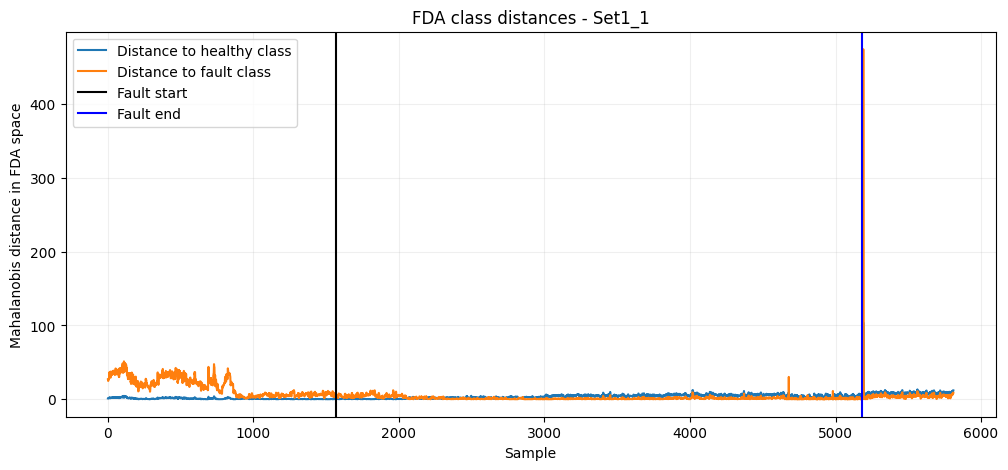

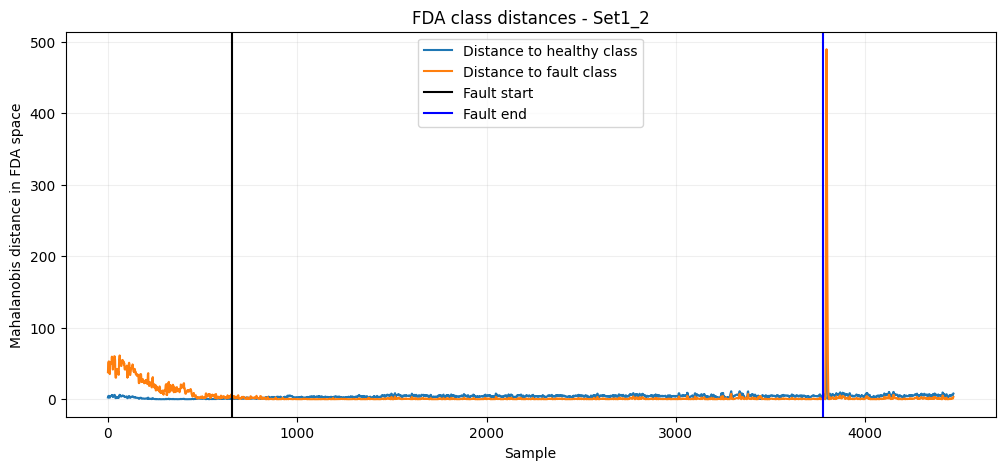

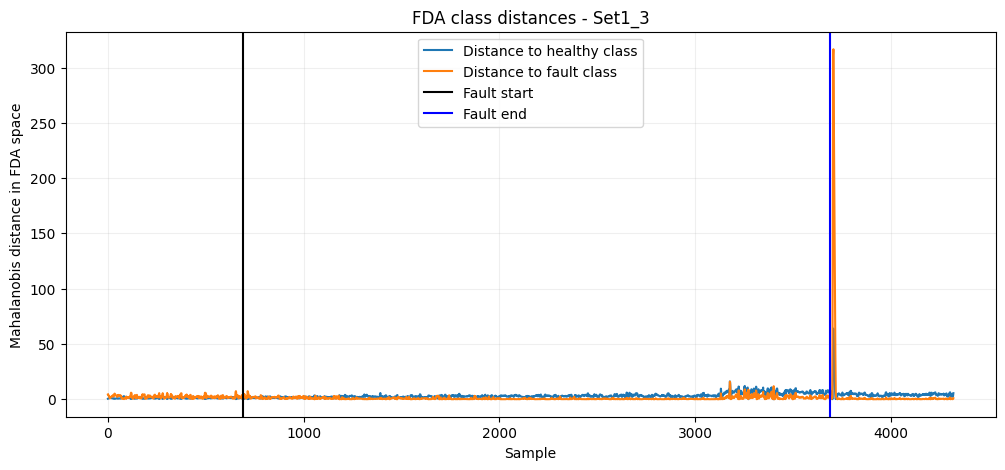

In [22]:
# ===============================
# FDA class-distance plots
# ===============================

for name, result in fda_results.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    plt.figure(figsize=(12, 5))
    plt.plot(result["distance_to_healthy"], label="Distance to healthy class")
    plt.plot(result["distance_to_fault"], label="Distance to fault class")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"FDA class distances - {name}")
    plt.xlabel("Sample")
    plt.ylabel("Mahalanobis distance in FDA space")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## FDA decision margin plots

Denne kodeblok viser selve FDA-beslutningen som en kontinuerlig score:
- Under 0: Modellen hælder mod healthy
- Over 0: Modellen hælder mod fault 

Det gør FDA langt lettere at forklare i rapporten

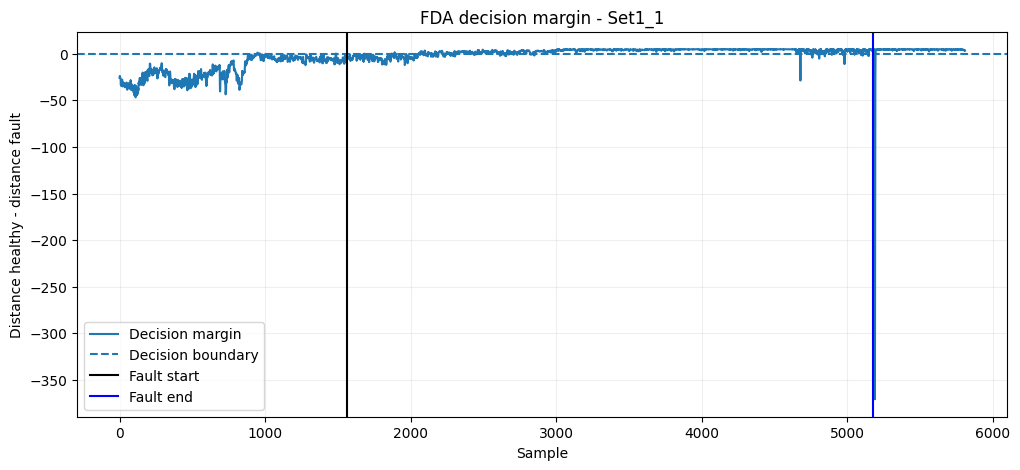

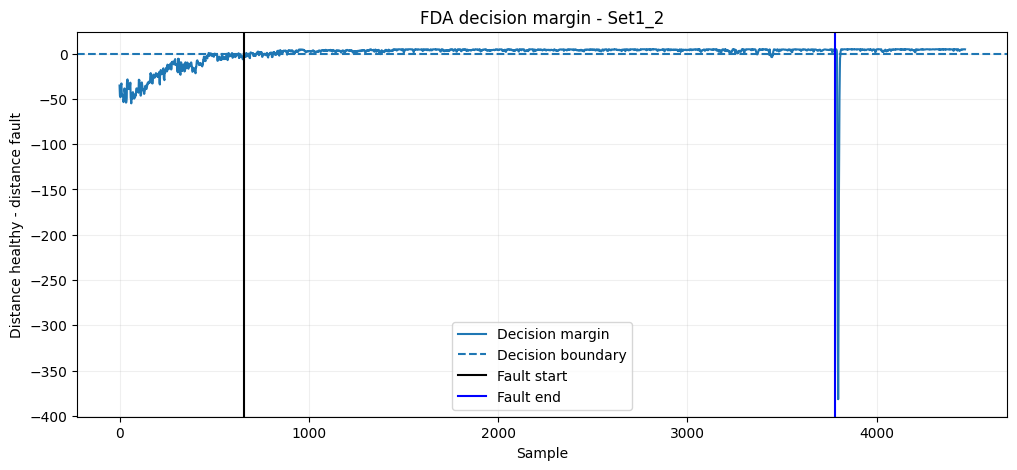

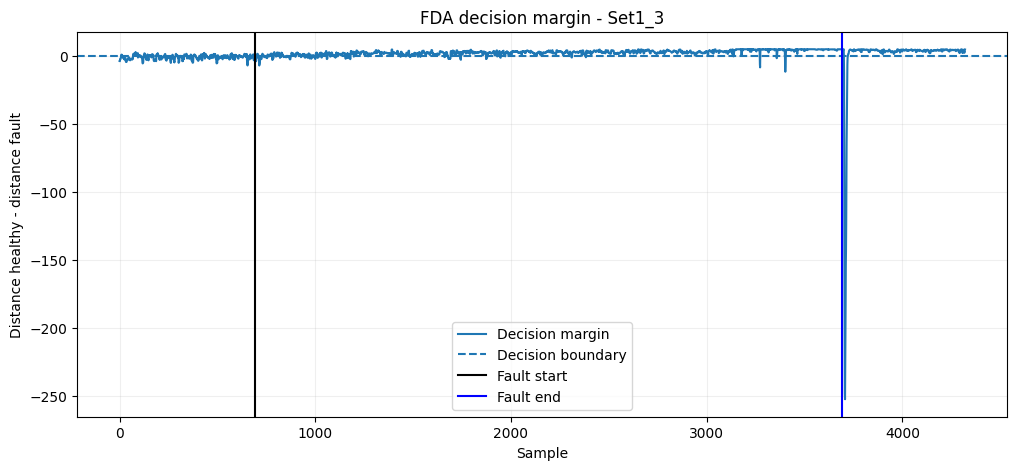

In [23]:
# ===============================
# FDA decision margin plots
# ===============================

for name, result in fda_results.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    plt.figure(figsize=(12, 5))
    plt.plot(result["decision_margin"], label="Decision margin")
    plt.axhline(0, linestyle="--", label="Decision boundary")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"FDA decision margin - {name}")
    plt.xlabel("Sample")
    plt.ylabel("Distance healthy - distance fault")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## Confusion matrix

Denne blok laver confusion matrix for hver datasæt, den viser:
- Hvor mange healthy samples der klassificeres korrekt 
- Hvor mange fault samples der klassificeres korrekt 
- Hvor mange false positives og false negatives der opstår

Det er en god FDA-graf, fordi FDA er en classifier

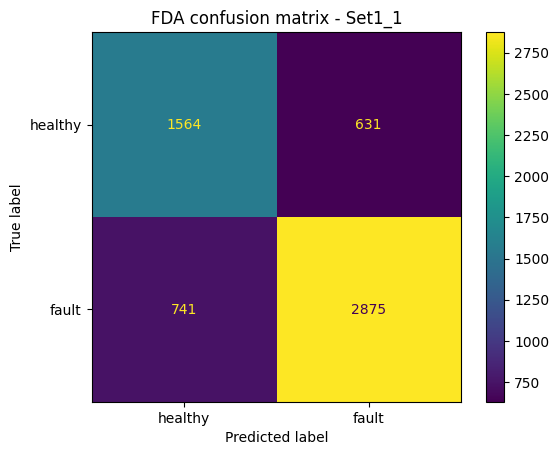

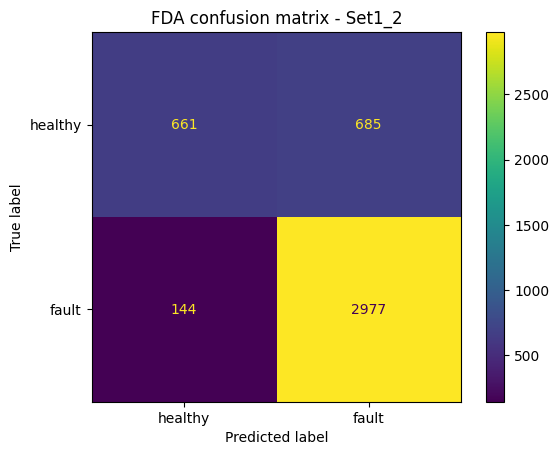

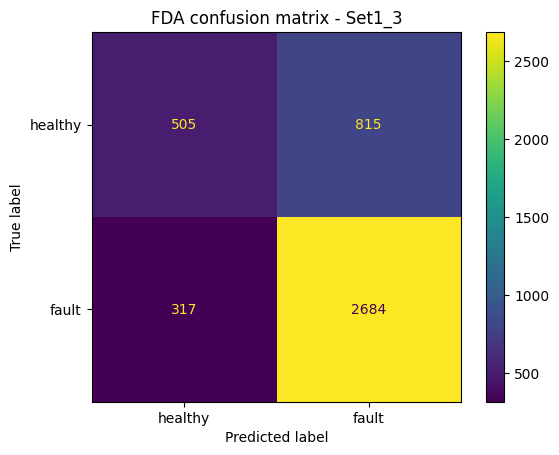

In [17]:
for name, result in fda_results.items():
    cm = confusion_matrix(result["y_true"], result["pred"])

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=["healthy", "fault"],
    )

    disp.plot()
    plt.title(f"FDA confusion matrix - {name}")
    plt.show()

## FDA projektion score 

Denne blok plotter FDA-score z1 over tid. Den viser, hvordan data bevæger sig i FDA-rummet, og om fault perioden adskiller sig fra normal drift. 

Fault-start og fault-end markeres med lodrette linjer. 

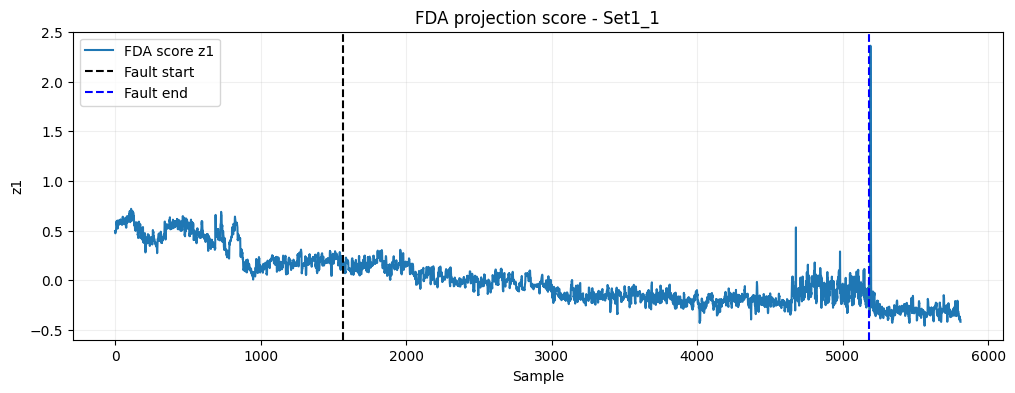

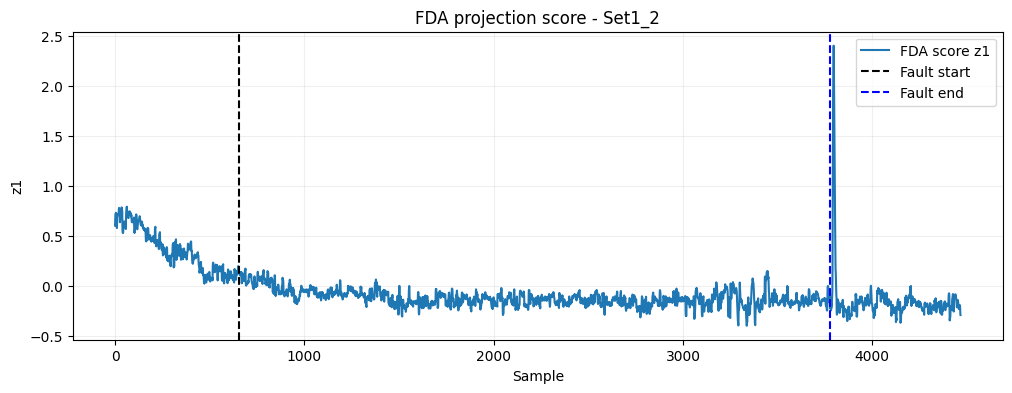

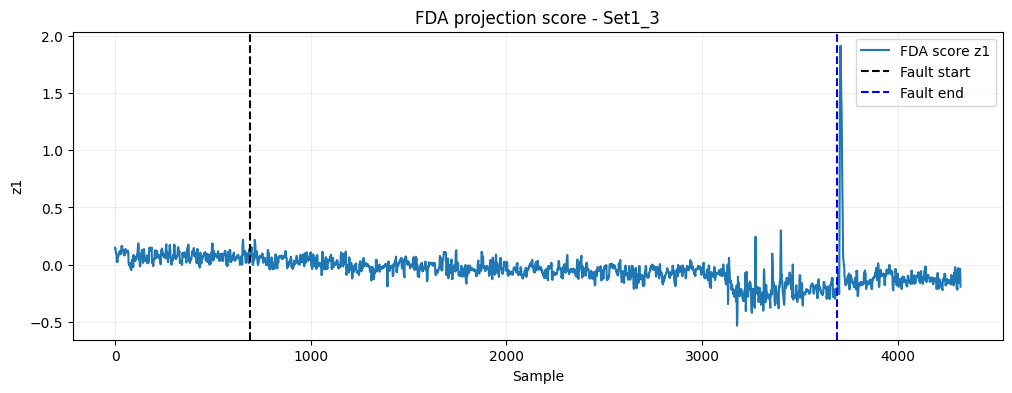

In [18]:
for name, result in fda_results.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    plt.figure(figsize=(12, 4))
    plt.plot(result["Z"][:, 0], label="FDA score z1")
    plt.axvline(fault_start, color="black", linestyle="--", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="--", label="Fault end")
    plt.title(f"FDA projection score - {name}")
    plt.xlabel("Sample")
    plt.ylabel("z1")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## Predicted class over time 

Denne blok plotter FDA's prediction over tid. Grafen viser direkte, hvornår modellen mener, at systemet er i fault. Dette er FDA-versionen af en binær alarmgraf

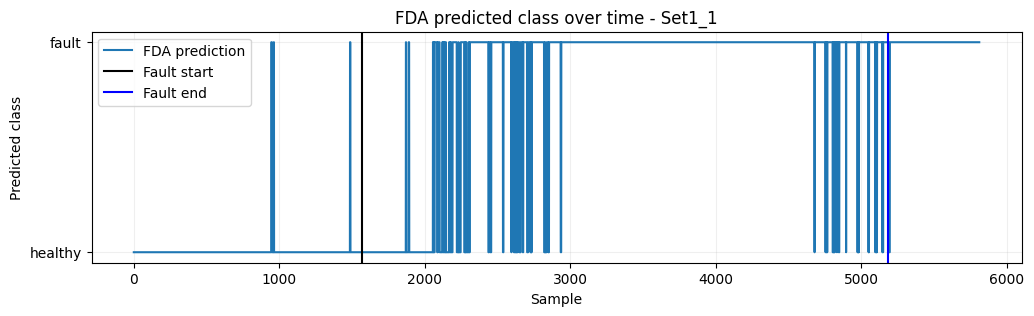

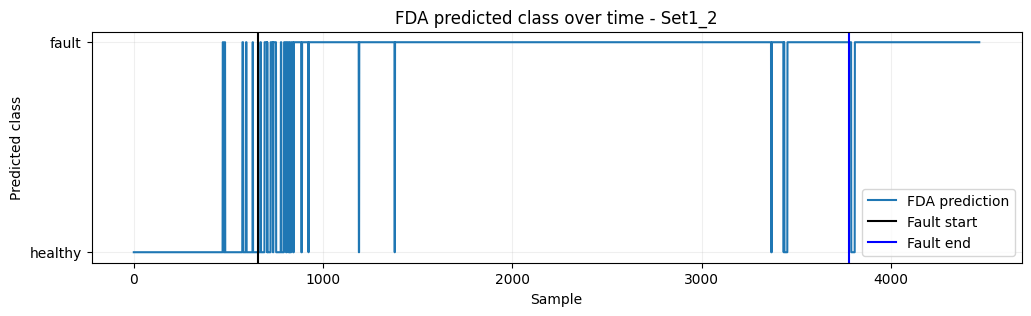

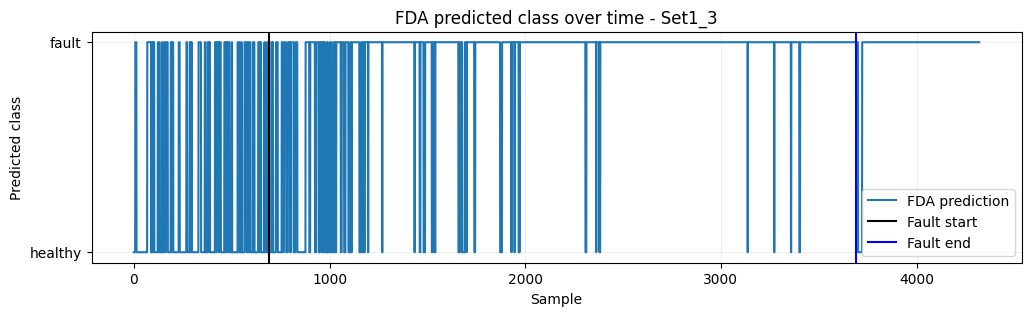

In [19]:
for name, result in fda_results.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    plt.figure(figsize=(12, 3))
    plt.plot(result["pred"], label="FDA prediction")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"FDA predicted class over time - {name}")
    plt.xlabel("Sample")
    plt.ylabel("Predicted class")
    plt.yticks([0, 1], ["healthy", "fault"])
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## FDA prediction vs. ground truth 

Den sammenligner FDA's prediction direkte med den rigtige fault-periode

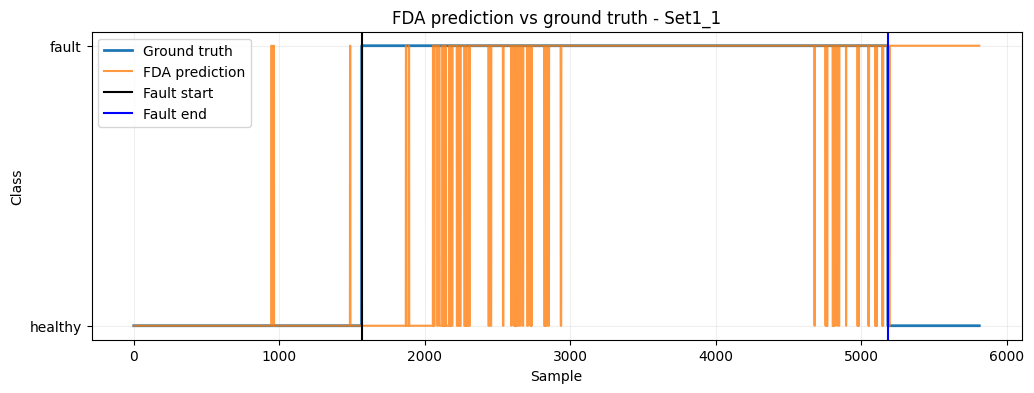

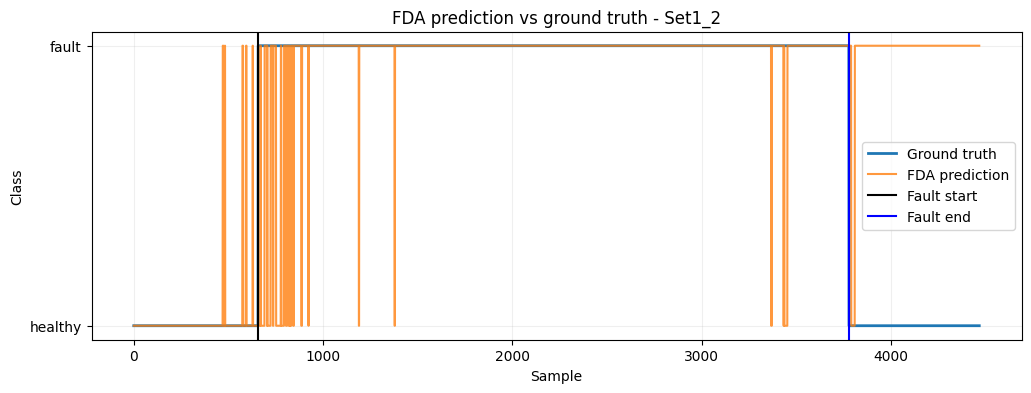

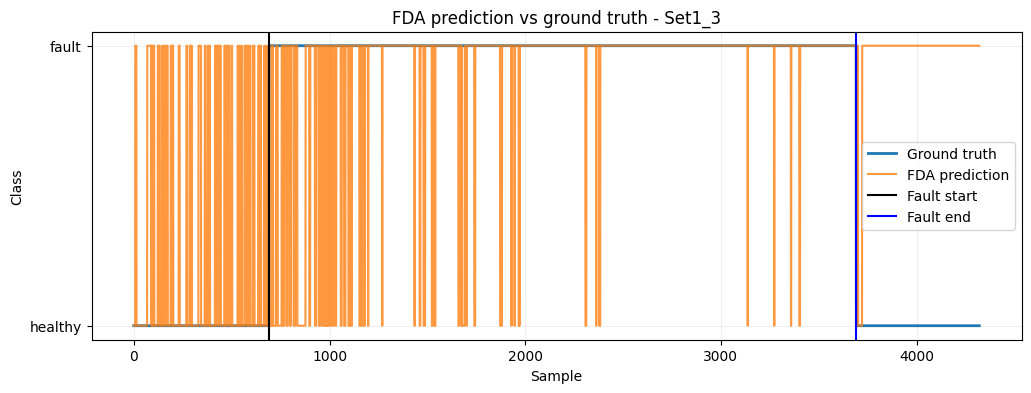

In [24]:
# ===============================
# FDA prediction vs ground truth
# ===============================

for name, result in fda_results.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    plt.figure(figsize=(12, 4))
    plt.plot(result["y_true"], label="Ground truth", linewidth=2)
    plt.plot(result["pred"], label="FDA prediction", alpha=0.8)
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"FDA prediction vs ground truth - {name}")
    plt.xlabel("Sample")
    plt.ylabel("Class")
    plt.yticks([0, 1], ["healthy", "fault"])
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## Fault diagnosis

## FDA variable importance

Denne kodeblok viser hvilke sensorer der vægter mest i FDA-retningen. Det hjælper for fault diagnosis, fordi der kan diskuteres hvilke sensorerer der bidrager mest til separationen mellem healthy og fault. 

,sensor,abs_fda_weight,fda_weight
5,Diff_P_Riser,0.660650,-0.660650
1,P_Bottom_Riser,0.504251,0.504251
3,P_Top_Separator,0.266484,0.266484
17,Temp_Water_In,0.244181,-0.244181
14,Density_Water_In,0.200584,-0.200584
4,P_3Phase_Separator,0.162287,-0.162287
2,P_Top_Riser,0.147418,-0.147418
7,Air_In_Flow,0.141474,-0.141474
21,Pos_VC101,0.131427,0.131427
20,Pos_VC302,0.129555,-0.129555


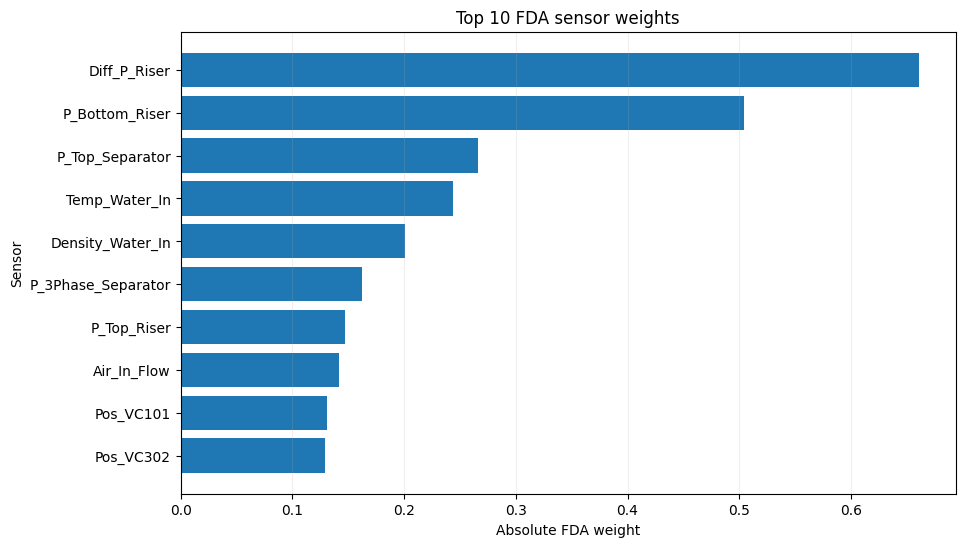

In [25]:
# ===============================
# FDA variable importance
# ===============================

fda_importance_df = pd.DataFrame({
    "sensor": fda_training_dataset.feature_names,
    "abs_fda_weight": np.abs(Wp[:, 0]),
    "fda_weight": Wp[:, 0],
}).sort_values("abs_fda_weight", ascending=False)

display(fda_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(
    fda_importance_df["sensor"].head(10)[::-1],
    fda_importance_df["abs_fda_weight"].head(10)[::-1],
)
plt.title("Top 10 FDA sensor weights")
plt.xlabel("Absolute FDA weight")
plt.ylabel("Sensor")
plt.grid(True, axis="x", alpha=0.2)
plt.show()